In [ ]:
import sys
from pathlib import Path

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_ROOT))

In [3]:
import kagglehub

# Esto descarga TODO el dataset (imágenes y CSVs) y te dice en qué carpeta de tu PC se ha guardado
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print("El dataset se ha descargado en:", path)

Resuming download from 8388608 bytes (5574525903 bytes left)...
Resuming download to C:\Users\carlo\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\2.archive (8388608/5582914511) bytes left.


100%|██████████| 5.20G/5.20G [04:39<00:00, 20.0MB/s] 

Extracting files...


El dataset se ha descargado en: C:\Users\carlo\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2


In [3]:
import kagglehub

path = kagglehub.dataset_download("tschandl/ham10000-lesion-segmentations")

print("Path to dataset files:", path)

100%|██████████| 10.3M/10.3M [00:01<00:00, 7.71MB/s]

Extracting files...


Path to dataset files: C:\Users\CARLOS\.cache\kagglehub\datasets\tschandl\ham10000-lesion-segmentations\versions\1


In [ ]:
#Imports
import os

#For reading the dataset
import pandas as pd
#import matplotlib.pyplot as plt
#from matplotlib.pyplot import subplots

from torch.utils.data import random_split, DataLoader
import torch
import config as c


# Skin Wounds Segmentation with PyTorch

### By Carlos Parra Camacho

----

## 1. Introduction 

For this project, I used Deep Learning techniques to segment skin lesions from the Kaggle HAM10000 dataset. This dataset provides 10,000 dermatoscopic images from various populations, acquired and stored through different modalities.

The goal is to isolate the lesion from the background to provide better visibility, helping to determine whether the wound is improving or if it requires medical attention.

---

# 2. Data

In [7]:
# 1. We define the directory where the data is
data_dir = r'C:\Users\carlo\WoundSegmentation\data'

# 2. Join the folder to the csv file
csv_path = os.path.join(data_dir, 'HAM10000_metadata.csv')

# 3. load the file with Pandas using the hole path
dataset = pd.read_csv(csv_path)

# 4. Show the head
print(dataset.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


## 2.1 Summary of Variables within the data

The HAM10000 dataset has 7 columns and 10015 rows in total. All variables are explained in this section, their units, their types and some descriptive statistics.

* Lesion_id - ID
    * Number of missing values = 0

* Image_id - Image Identifier
    * Number of missing values = 0

* dx - Diagnose
    * Number of missing values = 0
    * Contains 7 different values:
        - nv = Neveus melanocítico (Benign, common everydaty moles)
        - mel = Melanoma (Malignant, most dangerous skin cancer)
        - bcc = Basal cell carcinoma (Malignant/Invasive, but slow growing)
        - akiec = Actinic keratoses and intraepithelial carcinoma / Boewn's disease (Pre-cancerous)
        - bkl = Benign keratosis-like lesions (Seborrheic keratoses, non-cancerous warts)
        - df = Dermatofibroma (Benign, a type of skin nodule)
        - vasc = Vascular lesions (Benign, such as angiomas or pyogenic granulomas)
    
* dx_type - Confirmation Method
    * Number of missing values = 0
    * Contains 4 different values_
        - histopathology = Biopsia (The most reliable method; a tissue sample was cut and analyzed in a lab)
        - confocal = In-vivo confocal microscopy (Advanced live optical examination).
        - consensus = Expert consensus (Multiple dermatologists agreed on thhe diagnosis by looking at the image)
        - follow_ip = Monitoring (The lesion was monitored over months/years and did not change, confirming it was benign)

* age - Age
    * Number of missing values = 57
    * Contains patients between 0 and 85 years old

* sex - Sex
    * Number of missing values = 0
    * Contains 3 different values
        - Male
        - Female
        - Unknown

* localization - Location on the body
    * Number of missing values = 0
    * Contains 15 different values
        - back
        - lower extremity
        - trunk
        - upper extremity
        - abdomen
        - face
        - chest
        - foot
        - unknown
        - neck
        - scalp
        - hand
        - ear
        - genital
        - acral

## 2.3 dx class unbalance

As we can see, the dx which would be the target variable for a classification algorithm is pretty unbalanced which would be a problem. The big mayority of the patients had Benign moles.

In [9]:
print(dataset['dx'].value_counts())

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


## 2.4 Duplicated id values

In [17]:
duplicated = (dataset['id'].value_counts() > 1)
duplicated.value_counts()

count
False    5514
True     1956
Name: count, dtype: int64

We observe that we have 1956 IDs that are shown more than one time in the dataset. This means that 5514 IDs that appear just one time are a lesion that has only one photo and those who appear more than one time (up to 6 times some of them), are images from the same wound showing the evolution of the wound across the time. 

One goal of this project is to take advantage of those duplicated IDs to show how the wound evolve across time. Determining if the lesion's size increases or decreases.

# 3. Data Pre-Processing 

first of all we give the dataframe columns a conventional name (lowercase, whole words, etc)

In [19]:
dataset = dataset.rename(columns={
    'lesion_id' : 'id',
    'image_id' : 'image_id',
    'dx' : 'diagnose',
    'dx_type' : 'diagnose_method'
})

In [20]:
dataset.head(5)

,id,image_id,diagnose,diagnose_method,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


# 4. EDA

Before we dive into the image segmentation part, let's make some EDA for a better understanding of our data, we want to understand the shape of the data, what each variable look like and where values might be missing.

### 4.1 Distribution of the diagnose variable

This would be the target variable for classification techniques, it is interesting to know how it is distributed in this dataset.

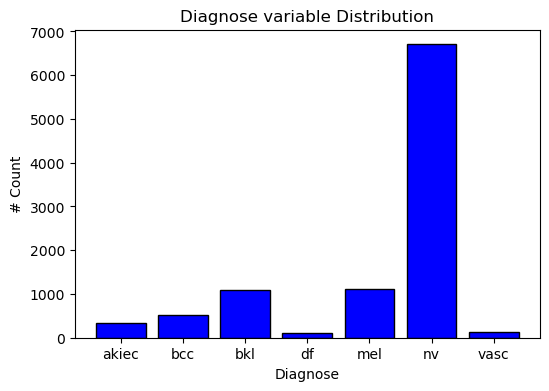

In [23]:
plt.figure(figsize=(6,4))

diagnose_counts = dataset['diagnose'].value_counts().sort_index()
plt.bar(diagnose_counts.index.astype(str), diagnose_counts.values, color='blue', edgecolor='black')
plt.title('Diagnose variable Distribution')
plt.xlabel('Diagnose')
plt.ylabel('# Count')

plt.show()

As we previously especified, we can observe a clear class unbalance as the 'nv' class is by far the vast majority of the classes. This must be a problem for classification techniques and we would need to apply some methods to deal with this.

### 4.2 Diagnose method distribution

now we will plot how the diagnose_method variable is distributed to see with which technique the diagnose has been made.

<BarContainer object of 4 artists>

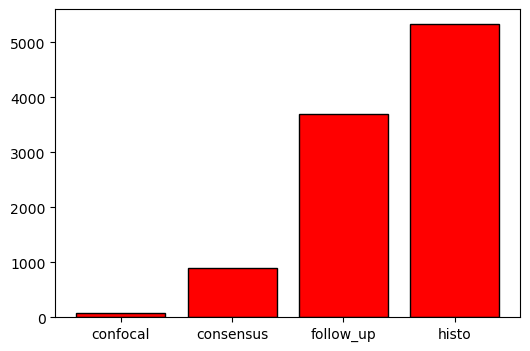

In [24]:
plt.figure(figsize=(6, 4))

diagnose_method_counts = dataset['diagnose_method'].value_counts().sort_index()
plt.bar(diagnose_method_counts.index.astype(str), diagnose_method_counts.values, color='red', edgecolor='black')

Tne majority of diagnoses were made by biopsia and following up the lesions with a smaller portion of cases of consensus between professionals and a minuet amound of confocal. 

# 5. Split and Dataloaders

In [3]:
from src.dataset import SkinLesionDataset

dataset = SkinLesionDataset()
print(f"Total samples: {len(dataset)}")

img, mask = dataset[0]
print(f"Image shape: {img.shape}")
print(f"Mask shape: {mask.shape}")

Total samples: 10015
Image shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])


In [ ]:
dataset_train, dataset_val, dataset_test = random_split(dataset, [0.8, 0.1, 0.1], generator=torch.Generator().manual_seed(42))

dataloader_train = DataLoader(
    dataset_train,
    batch_size=c.BATCH_SIZE,
    shuffle=True
)

dataloader_val = DataLoader(
    dataset_val,
    batch_size=c.BATCH_SIZE,
    shuffle=False
)

dataloader_test = DataLoader(
    dataset_test,   
    batch_size=c.BATCH_SIZE,
    shuffle=False
)